Objective:
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset. 
Exploratory Data Analysis (EDA):
1.Load the Titanic dataset using Python's pandas library.
2.Check for missing values.
3.Explore data distributions using histograms and box plots.
4.Visualize relationships between features and survival using scatter plots and bar plots.
Data Preprocessing:
1.Impute missing values.
2.Encode categorical variables using one-hot encoding or label encoding. 
3.If needed you can apply more preprocessing methods on the given dataset.
Building Predictive Models:
1.Split the preprocessed dataset into training and testing sets.
2.Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
3.Build predictive models using LightGBM and XGBoost algorithms.
4.Train the models on the training set and evaluate their performance on the testing set.
5.Use techniques like cross-validation and hyperparameter tuning to optimize model performance.
Comparative Analysis:
1.Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
2.Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.
Submission Requirements:
Well-commented code explaining each step of the analysis.
Visualizations with appropriate titles and labels.
A brief report summarizing the comparative analysis results and practical implications.


Exploratory Data Analysis (EDA):
1.Load the Titanic dataset using Python's pandas library.
2.Check for missing values.
3.Explore data distributions using histograms and box plots.
4.Visualize relationships between features and survival using scatter plots and bar plots.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("diabetes (1).csv")

In [6]:
df.shape

(768, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

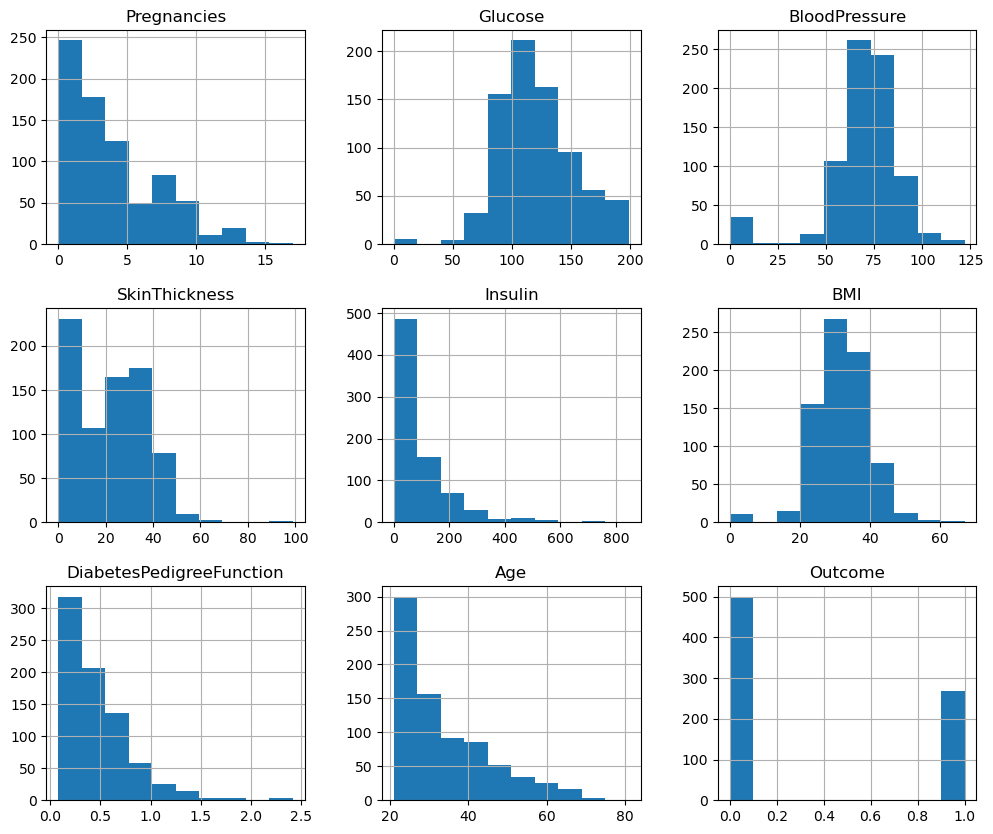

In [13]:
df.hist(figsize=(12,10))
plt.show()

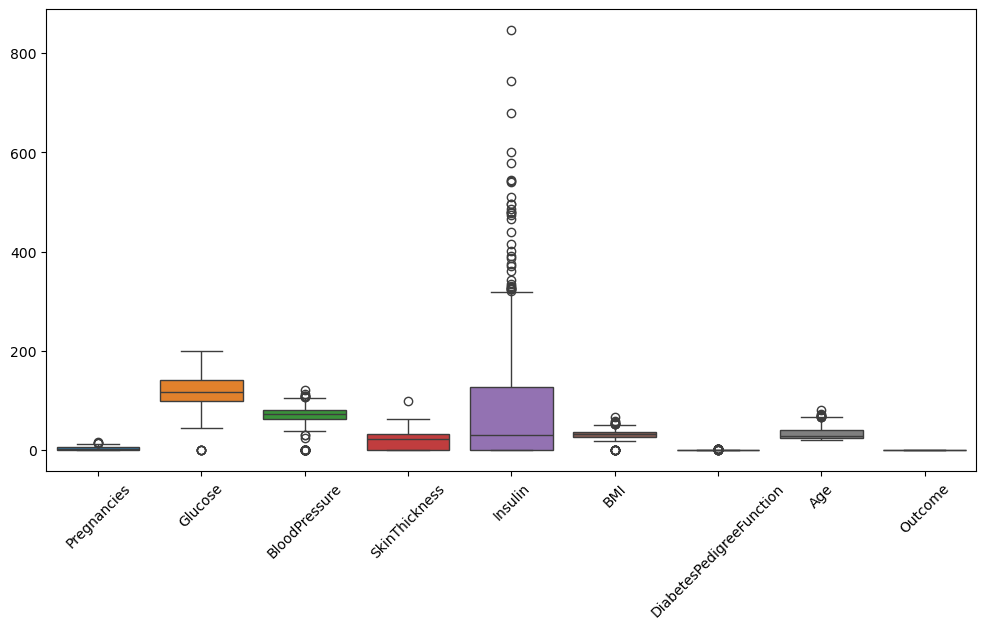

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()
           

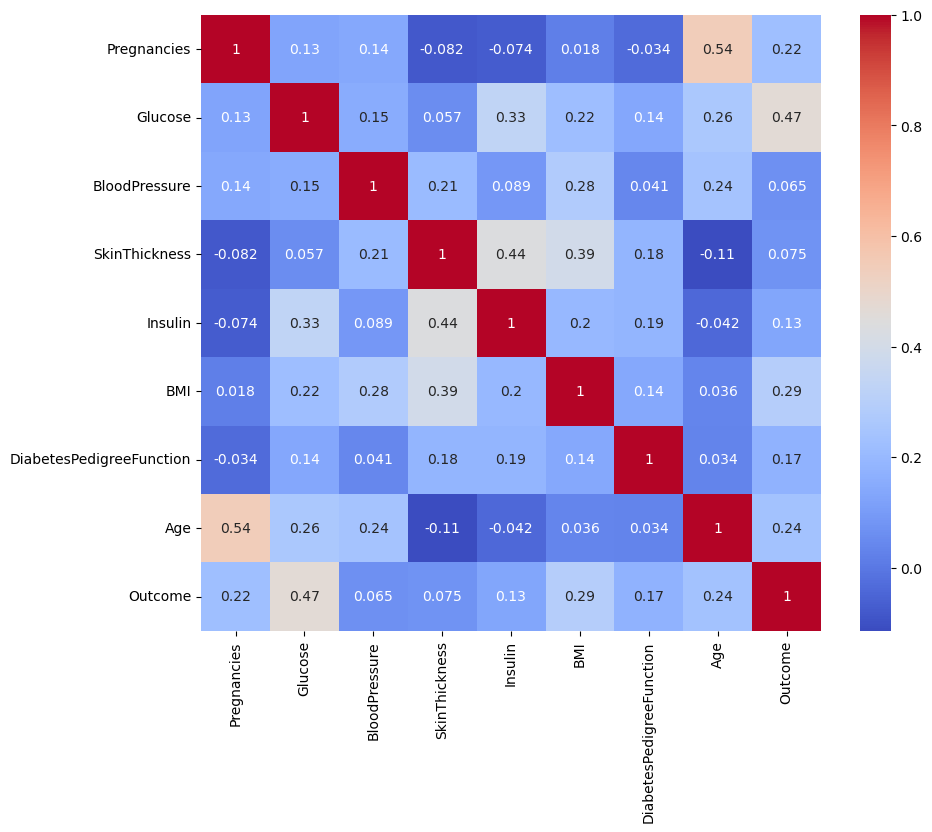

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Data Preprocessing:
1.Impute missing values.
2.Encode categorical variables using one-hot encoding or label encoding. 
3.If needed you can apply more preprocessing methods on the given dataset.

In [17]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [19]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [20]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [21]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

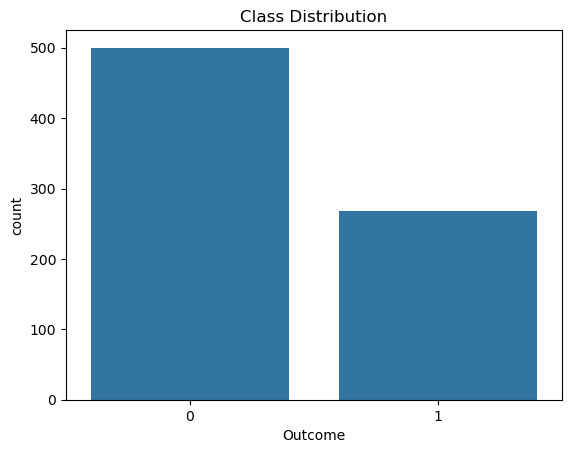

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

Building Predictive Models:
1.Split the preprocessed dataset into training and testing sets.
2.Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
3.Build predictive models using LightGBM and XGBoost algorithms.
4.Train the models on the training set and evaluate their performance on the testing set.
5.Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [25]:
!pip install lightgbm xgboost

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ---------------

In [34]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [38]:
from sklearn.model_selection import cross_val_score

cv_lgbm = cross_val_score(lgbm, X_scaled, y, cv=5)

print("LightGBM CV Accuracy:", cv_lgbm.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [39]:
from sklearn.metrics import accuracy_score

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("XGBoost Accuracy :", accuracy_score(y_test, y_pred_xgb))

LightGBM Accuracy: 0.7532467532467533
XGBoost Accuracy : 0.7337662337662337


Comparative Analysis:
1.Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
2.Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# LightGBM Metrics
print("------ LightGBM ------")
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))

print()

# XGBoost Metrics
print("------ XGBoost ------")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

------ LightGBM ------
Accuracy : 0.7532467532467533
Precision: 0.6349206349206349
Recall   : 0.7272727272727273
F1 Score : 0.6779661016949152

------ XGBoost ------
Accuracy : 0.7337662337662337
Precision: 0.6060606060606061
Recall   : 0.7272727272727273
F1 Score : 0.6611570247933884


      Metric  LightGBM   XGBoost
0   Accuracy  0.753247  0.733766
1  Precision  0.634921  0.606061
2     Recall  0.727273  0.727273
3   F1 Score  0.677966  0.661157


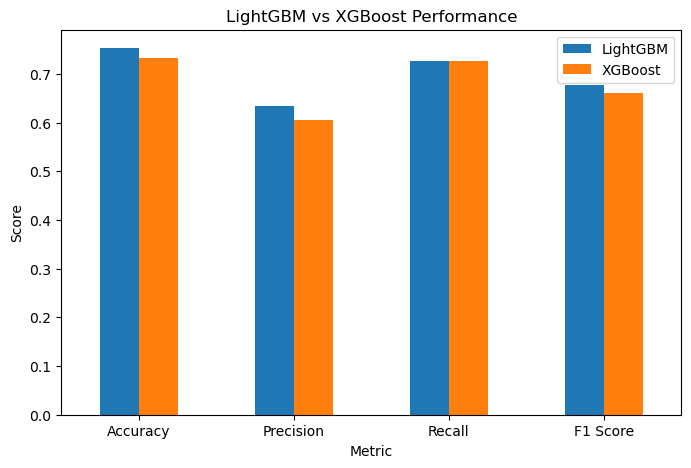

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "LightGBM":[
        accuracy_score(y_test,y_pred_lgbm),
        precision_score(y_test,y_pred_lgbm),
        recall_score(y_test,y_pred_lgbm),
        f1_score(y_test,y_pred_lgbm)
    ],
    "XGBoost":[
        accuracy_score(y_test,y_pred_xgb),
        precision_score(y_test,y_pred_xgb),
        recall_score(y_test,y_pred_xgb),
        f1_score(y_test,y_pred_xgb)
    ]
})

print(results)

results.set_index("Metric").plot(kind="bar", figsize=(8,5))
plt.title("LightGBM vs XGBoost Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

---LightGBM
Faster training.
Less memory usage.
Works well on large datasets.

---XGBoostHigh accuracy.
Better regularization.
Slightly slower than LightGBM.

## Conclusion

- LightGBM and XGBoost are powerful gradient boosting algorithms.
- Both models were trained and evaluated using the diabetes dataset.
- Performance was measured using Accuracy, Precision, Recall, and F1-score.
- The comparison showed which model performed better on the dataset.
- LightGBM trained faster, while XGBoost provided competitive predictive performance.